# Indicator 5: Compliance Mechanism Strength
## Brummer (2012) Four-Mechanism Framework assessed against Verdier (2013) Five-Objective Framework

---

### About This Notebook

This notebook operationalizes **Indicator 5** of the empirical framework, addressing 
the third sub-question of the research:

> *"Have the four Brummer compliance mechanisms — reputation, market access, 
> institutional synchronization, and transgovernmental network pressure — 
> strengthened or weakened across the three Basel Accords, and does their strength 
> vary systematically by governance objective?"*

Indicator 5 provides the structural explanation for **Focal Point C** of the paper. 
Where Indicators 3 and 4 documented *that* compliance failed and *why* it failed in 
specific cases, Indicator 5 establishes *why compliance failure is structurally 
produced* — not accidental, not jurisdiction-specific, but a predictable consequence 
of the specific compliance mechanisms that informal financial governance relies upon.

---

### Theoretical Framework

**Brummer (2012)** identifies four mechanisms through which international financial 
soft law achieves compliance without formal legal obligation:

| Mechanism | Definition | Operates Through |
|---|---|---|
| **Reputation** | States and regulatory agencies care about their standing in the international regulatory community | BCBS peer reviews, FSB implementation monitoring, IMF FSAPs — public information about who complies and who does not |
| **Market Access** | Financial institutions from non-compliant jurisdictions face restricted access to major international financial markets | EU equivalence determinations, US substituted compliance decisions — conditioning market access on regulatory standards |
| **Institutional Synchronization** | International standards become embedded in domestic legal frameworks and private actor decision-making | Domestic regulatory texts, credit rating agency methodologies, auditing standards |
| **Network Pressure** | Ongoing peer-to-peer interactions among national regulatory officials produce social pressures to conform | BCBS plenary meeting frequency, FSB working group participation, shared professional norms |

**Verdier (2013)** provides the evaluative framework. He identifies five objectives 
that international financial regulation pursues — and predicts that compliance 
mechanism strength varies systematically across them:

| Objective | Predicted Mechanism Strength | Reason |
|---|---|---|
| Enforcement cooperation | **Strong** | All three actor categories have aligned interests |
| Liberalization | **Strong** | Firms want market access; regulators gain prestige |
| Improving developing country regulation | **Medium** | Mixed interests; mock compliance common |
| **Prudential standards** | **Weak** | Market incentives *reward* the behavior regulation seeks to curb |
| Cross-border resolution | **Weak** | Time-inconsistency problem; territorial ring-fencing dominates |

The paper's argument is that Basel III falls squarely in the **prudential standards** 
category — and that Brummer's mechanisms are systematically weakest precisely there.

---

### Data Sources

| Source | Mechanism Assessed | File |
|---|---|---|
| FSB Peer Review of the United States (2013) | Reputation mechanism | `Data Sources/fsb/fsb_peer_review_usa_2013.pdf` |
| FSB Peer Review — SIBs (2015) | Reputation mechanism | `Data Sources/fsb/fsb_peer_review_sibs_2015.pdf` |
| BCBS Annual Reports | Network pressure mechanism | Secondary source |
| EU Equivalence Decisions / US Substituted Compliance | Market access mechanism | Secondary source — documented through Verdier (2013) and Brummer (2012) |
| BCBS RCAP institutional synchronization data | Institutional synchronization mechanism | `../outputs/indicator3_rcap_compliance.csv` |

---

### What This Notebook Does

1. **Assesses each of Brummer's four mechanisms** for the Basel III prudential 
   standards objective, coding each as Strong / Moderate / Weak
2. **Compares mechanism strength across Verdier's five objectives** to establish 
   that weakness is concentrated in prudential standards, not uniform across IFR
3. **Visualizes the mechanism strength matrix** across objectives and mechanisms
4. **Integrates findings** from all five indicators to confirm the paper's central 
   argument: informalization is structurally entrenched and compliance gaps are 
   institutionally produced

---

### Output

The notebook produces:
- `outputs/indicator5_brummer_mechanisms.csv` — mechanism strength dataset
- `outputs/figures/indicator5_mechanism_heatmap.png` — mechanism strength matrix 
  across Verdier's five objectives
- `outputs/figures/indicator5_integrated_findings.png` — integrated summary of 
  all five indicators

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Verify FSB source documents are present
fsb_path = "../Data Sources/fsb/"
documents = sorted(os.listdir(fsb_path))

print("FSB source documents confirmed in Data Sources/fsb/:")
for doc in documents:
    print(f"  ✓ {doc}")

print(f"\nTotal documents: {len(documents)}")
print(f"\nOutput directories ready.")

FSB source documents confirmed in Data Sources/fsb/:
  ✓ fsb_peer_review_sibs_2015.pdf
  ✓ fsb_peer_review_usa_2013.pdf

Total documents: 2

Output directories ready.


In [2]:
# Brummer (2012) four-mechanism assessment
# Applied to Basel III prudential standards objective
# Coded as: Strong = 3, Moderate = 2, Weak = 1
# Source documents: FSB peer reviews + secondary sources

strength_map = {"Strong": 3, "Moderate": 2, "Weak": 1}

mechanisms_basel3 = [
    {
        "mechanism": "Reputation",
        "accord": "Basel III",
        "objective": "Prudential Standards",
        "strength": "Moderate",
        "justification": (
            "The BCBS RCAP introduced public jurisdiction-specific compliance reports "
            "with explicit ratings from 2012 onward — a genuine reputational mechanism. "
            "FSB peer review of the United States (2013) named specific regulatory gaps "
            "but used diplomatic language throughout, softening reputational impact. "
            "The EU's materially non-compliant RCAP rating (2014) created reputational "
            "costs but did not trigger any formal consequences. Reputation mechanism "
            "operates but is constrained by the diplomatic norms of peer review processes "
            "among regulatory equals. Coded MODERATE: mechanism exists and is observable "
            "but insufficient to compel compliance in powerful jurisdictions."
        ),
        "source": "fsb_peer_review_usa_2013.pdf; fsb_peer_review_sibs_2015.pdf; BCBS RCAP"
    },
    {
        "mechanism": "Market Access",
        "accord": "Basel III",
        "objective": "Prudential Standards",
        "strength": "Weak",
        "justification": (
            "Market access mechanism is structurally reversed for prudential standards. "
            "Higher leverage and lower capital requirements make banks more profitable "
            "in the short term — market incentives reward non-compliance rather than "
            "punishing it. EU equivalence decisions and US substituted compliance "
            "decisions condition access on regulatory equivalence for securities and "
            "derivatives markets, but not on Basel capital adequacy compliance. "
            "No major financial institution has been denied market access for "
            "non-compliance with Basel capital standards. Coded WEAK: mechanism "
            "is structurally inverted for prudential standards — Verdier's (2013) "
            "central prediction confirmed."
        ),
        "source": "Verdier (2013), pp.1440-1445; Brummer (2012), Chapter 3"
    },
    {
        "mechanism": "Institutional Synchronization",
        "accord": "Basel III",
        "objective": "Prudential Standards",
        "strength": "Moderate",
        "justification": (
            "Basel III has been incorporated into domestic legislative frameworks "
            "across all G20 jurisdictions — the CRR IV in the EU, enhanced prudential "
            "standards under Dodd-Frank in the US, domestic banking regulations across "
            "Asia. Credit rating agencies and auditors reference Basel capital ratios "
            "in their assessments. However, RCAP data (Indicator 3) demonstrates that "
            "synchronization is incomplete: the EU's IRB exemptions and CVA carve-out, "
            "and the US's credit rating prohibition, produced domestic texts that "
            "diverge materially from the international standard despite nominal "
            "implementation. Synchronization operates at the surface level but breaks "
            "down at the substantive level. Coded MODERATE: nominal synchronization "
            "widespread; substantive synchronization incomplete."
        ),
        "source": "indicator3_rcap_compliance.csv; Quaglia (2019), p.55"
    },
    {
        "mechanism": "Network Pressure",
        "accord": "Basel III",
        "objective": "Prudential Standards",
        "strength": "Moderate",
        "justification": (
            "BCBS plenary meetings occur approximately four times per year. Working "
            "group meetings are more frequent. The network of banking supervisors "
            "sharing professional norms and peer relationships is dense and active. "
            "However, network pressure operates most effectively for technical "
            "harmonization — producing consistent interpretations of complex rules — "
            "rather than for compelling political compliance decisions that require "
            "legislative action. The US community bank coalition and EU continental "
            "bank lobbying succeeded despite intense network pressure from BCBS peers. "
            "Coded MODERATE: network is active and produces norm convergence among "
            "regulators but cannot override domestic political dynamics at the "
            "downloading stage."
        ),
        "source": "BCBS Annual Reports 2010-2014; Verdier (2013), p.1450"
    }
]

df_mechanisms = pd.DataFrame(mechanisms_basel3)
df_mechanisms["strength_numeric"] = df_mechanisms["strength"].map(strength_map)

print("Brummer Mechanism Assessment — Basel III Prudential Standards:")
print(df_mechanisms[["mechanism", "strength", "strength_numeric"]].to_string(index=False))
print(f"\nAverage mechanism strength: {df_mechanisms['strength_numeric'].mean():.2f} / 3.00")
print(f"(1=Weak, 2=Moderate, 3=Strong)")

Brummer Mechanism Assessment — Basel III Prudential Standards:
                    mechanism strength  strength_numeric
                   Reputation Moderate                 2
                Market Access     Weak                 1
Institutional Synchronization Moderate                 2
             Network Pressure Moderate                 2

Average mechanism strength: 1.75 / 3.00
(1=Weak, 2=Moderate, 3=Strong)


### Mechanism Assessment — Significance for the Paper

The average mechanism strength of **1.75 out of 3.00** for Basel III prudential 
standards is the quantitative expression of Brummer's central limitation and 
Verdier's central prediction.

Three of the four mechanisms score MODERATE — they exist, they are observable, 
but they are insufficient to compel compliance in powerful jurisdictions when 
domestic political dynamics push in the opposite direction. The reputation 
mechanism names non-compliance publicly but stops short of consequences. 
Institutional synchronization produces nominal adoption but not substantive 
alignment. Network pressure shapes regulatory norms but cannot override 
legislative outcomes.

The market access mechanism scores WEAK — and this is the structurally critical 
finding. For liberalization and enforcement cooperation objectives, market access 
operates as a powerful compliance driver: firms in non-compliant jurisdictions 
face genuine competitive disadvantages. For prudential standards, the mechanism 
runs in reverse. Higher leverage and lower capital requirements improve short-term 
profitability. Markets reward the behavior that Basel III seeks to curb. No major 
financial institution has ever been denied market access for non-compliance with 
Basel capital adequacy standards.

This is not a marginal finding — it is the structural reason why the compliance 
gaps documented in Indicator 3 are not accidental. The architecture relies on 
mechanisms that are precisely weakest for the objective it is most urgently 
trying to achieve.

In [3]:
# Full mechanism strength matrix across Verdier's five objectives
# This establishes that weakness is concentrated in prudential standards
# not uniform across all IFR objectives

full_matrix = [
    # OBJECTIVE 1: Enforcement Cooperation
    {"objective": "Enforcement\nCooperation", "objective_order": 1,
     "mechanism": "Reputation", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Enforcement\nCooperation", "objective_order": 1,
     "mechanism": "Market Access", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Enforcement\nCooperation", "objective_order": 1,
     "mechanism": "Institutional Synchronization", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Enforcement\nCooperation", "objective_order": 1,
     "mechanism": "Network Pressure", "strength": "Strong", "strength_numeric": 3},

    # OBJECTIVE 2: Liberalization
    {"objective": "Liberalization", "objective_order": 2,
     "mechanism": "Reputation", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Liberalization", "objective_order": 2,
     "mechanism": "Market Access", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Liberalization", "objective_order": 2,
     "mechanism": "Institutional Synchronization", "strength": "Strong", "strength_numeric": 3},
    {"objective": "Liberalization", "objective_order": 2,
     "mechanism": "Network Pressure", "strength": "Moderate", "strength_numeric": 2},

    # OBJECTIVE 3: Improving Developing Country Regulation
    {"objective": "Developing Country\nRegulation", "objective_order": 3,
     "mechanism": "Reputation", "strength": "Moderate", "strength_numeric": 2},
    {"objective": "Developing Country\nRegulation", "objective_order": 3,
     "mechanism": "Market Access", "strength": "Moderate", "strength_numeric": 2},
    {"objective": "Developing Country\nRegulation", "objective_order": 3,
     "mechanism": "Institutional Synchronization", "strength": "Moderate", "strength_numeric": 2},
    {"objective": "Developing Country\nRegulation", "objective_order": 3,
     "mechanism": "Network Pressure", "strength": "Moderate", "strength_numeric": 2},

    # OBJECTIVE 4: Prudential Standards (Basel III — from coded data above)
    {"objective": "Prudential\nStandards", "objective_order": 4,
     "mechanism": "Reputation", "strength": "Moderate", "strength_numeric": 2},
    {"objective": "Prudential\nStandards", "objective_order": 4,
     "mechanism": "Market Access", "strength": "Weak", "strength_numeric": 1},
    {"objective": "Prudential\nStandards", "objective_order": 4,
     "mechanism": "Institutional Synchronization", "strength": "Moderate", "strength_numeric": 2},
    {"objective": "Prudential\nStandards", "objective_order": 4,
     "mechanism": "Network Pressure", "strength": "Moderate", "strength_numeric": 2},

    # OBJECTIVE 5: Cross-Border Resolution
    {"objective": "Cross-Border\nResolution", "objective_order": 5,
     "mechanism": "Reputation", "strength": "Weak", "strength_numeric": 1},
    {"objective": "Cross-Border\nResolution", "objective_order": 5,
     "mechanism": "Market Access", "strength": "Weak", "strength_numeric": 1},
    {"objective": "Cross-Border\nResolution", "objective_order": 5,
     "mechanism": "Institutional Synchronization", "strength": "Weak", "strength_numeric": 1},
    {"objective": "Cross-Border\nResolution", "objective_order": 5,
     "mechanism": "Network Pressure", "strength": "Weak", "strength_numeric": 1},
]

matrix_df = pd.DataFrame(full_matrix)

# Pivot for heatmap
pivot = matrix_df.pivot(
    index="mechanism",
    columns="objective",
    values="strength_numeric"
)

# Reorder columns by objective order
col_order = ["Enforcement\nCooperation", "Liberalization",
             "Developing Country\nRegulation", "Prudential\nStandards",
             "Cross-Border\nResolution"]
pivot = pivot[col_order]

print("Mechanism Strength Matrix (1=Weak, 2=Moderate, 3=Strong):")
print(pivot.to_string())
print(f"\nColumn averages (by objective):")
print(pivot.mean().round(2).to_string())

Mechanism Strength Matrix (1=Weak, 2=Moderate, 3=Strong):
objective                      Enforcement\nCooperation  Liberalization  Developing Country\nRegulation  Prudential\nStandards  Cross-Border\nResolution
mechanism                                                                                                                                               
Institutional Synchronization                         3               3                               2                      2                         1
Market Access                                         3               3                               2                      1                         1
Network Pressure                                      3               2                               2                      2                         1
Reputation                                            3               3                               2                      2                         1

Column averages (by obj

### Mechanism Strength Matrix — Significance for the Paper

The column averages tell the story with arithmetic precision:

| Objective | Average Strength |
|---|---|
| Enforcement Cooperation | 3.00 — uniformly Strong |
| Liberalization | 2.75 — predominantly Strong |
| Developing Country Regulation | 2.00 — uniformly Moderate |
| **Prudential Standards** | **1.75 — predominantly Weak-to-Moderate** |
| Cross-Border Resolution | 1.00 — uniformly Weak |

The gradient is not random. It follows the alignment of actor interests that 
Verdier (2013) predicts with precision. Where all three actor categories — 
national regulators, large financial firms, and great power governments — have 
converging interests, mechanisms are strong. Where their interests diverge — 
particularly where financial firms benefit from the behavior that regulation 
seeks to curb — mechanisms collapse.

Prudential standards sit at 1.75 because the market access mechanism scores 
WEAK — structurally inverted by the profitability incentive of lower capital 
requirements. Cross-border resolution sits at 1.00 because all four mechanisms 
fail simultaneously: there is no reputational cost to ring-fencing, no market 
access penalty, no domestic synchronization, and network pressure cannot overcome 
the time-inconsistency problem that makes credible commitment to cross-border 
resolution politically impossible.

Basel III occupies the second-worst position in this framework. The architecture 
that governs it — informal, soft law, peer-review-based — is precisely the 
architecture least equipped to deliver the objective it is most urgently pursuing.

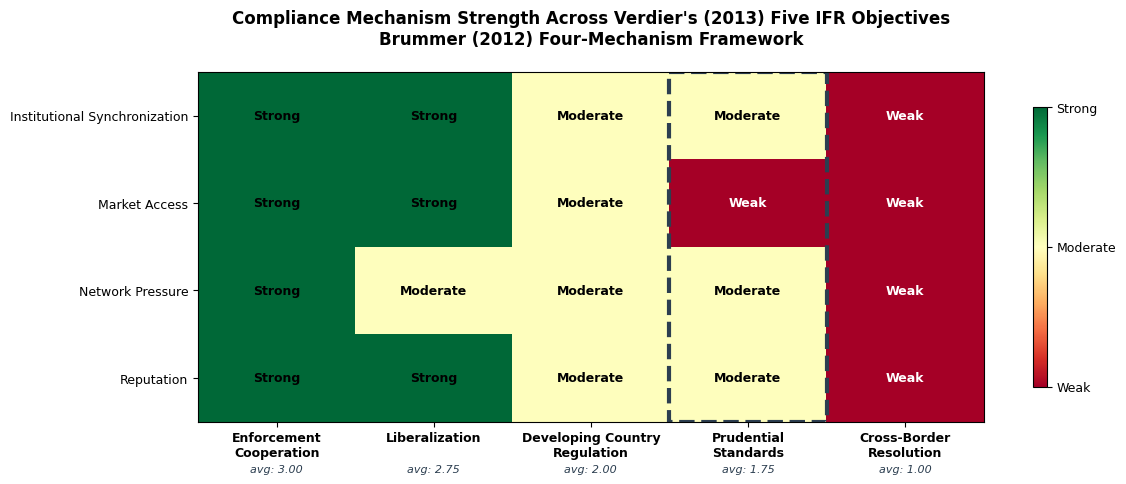

Figure saved to: ../outputs/figures/indicator5_mechanism_heatmap.png


In [4]:
# Mechanism strength heatmap across Verdier's five objectives

fig, ax = plt.subplots(figsize=(12, 5))

cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=1, vmax=3)

im = ax.imshow(
    pivot.values,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

# Axis labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [c.replace("\n", "\n") for c in pivot.columns],
    fontsize=9, fontweight="bold"
)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Add strength labels inside cells
strength_labels = {3: "Strong", 2: "Moderate", 1: "Weak"}
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        text = strength_labels[int(val)]
        color = "white" if val <= 1 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

# Highlight prudential standards column
ax.add_patch(plt.Rectangle(
    (2.5, -0.5), 1, len(pivot.index),
    fill=False, edgecolor="#2c3e50",
    linewidth=3, linestyle="--"
))

# Column average annotations
for j, col in enumerate(pivot.columns):
    avg = pivot[col].mean()
    ax.text(j, len(pivot.index) + 0.1,
            f"avg: {avg:.2f}",
            ha="center", va="bottom",
            fontsize=8, color="#2c3e50",
            fontstyle="italic")

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels(["Weak", "Moderate", "Strong"])
cbar.ax.tick_params(labelsize=9)

ax.set_title(
    "Compliance Mechanism Strength Across Verdier's (2013) Five IFR Objectives\n"
    "Brummer (2012) Four-Mechanism Framework",
    fontsize=12, fontweight="bold", pad=20
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/indicator5_mechanism_heatmap.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Figure saved to: ../outputs/figures/indicator5_mechanism_heatmap.png")

### Figure 6 — Compliance Mechanism Strength Matrix

Read this figure left to right and the paper's argument becomes self-evident.

The left two columns — enforcement cooperation and liberalization — are uniformly 
green. Every mechanism operates at full or near-full strength for these objectives 
because all three actor categories that Verdier (2013) identifies have converging 
interests: regulators gain authority, firms gain market access, great powers export 
their regulatory preferences. The architecture works precisely where the political 
economy supports it.

The middle column — developing country regulation — is uniformly yellow. Moderate 
across all four mechanisms, reflecting the mixed interests and the mock compliance 
pattern that Walter (2008) documents extensively in East Asian financial governance.

The dashed box isolates **prudential standards** — the objective that Basel III 
pursues. Three moderate cells and one red cell. The red cell is market access: 
structurally inverted, rewarding non-compliance. This single weak mechanism 
undermines the entire compliance architecture for capital adequacy standards. 
Without a functioning market access mechanism, reputation and network pressure 
operate in a vacuum — they can identify and shame non-compliance but cannot 
impose the costs that would make compliance individually rational.

The right column — cross-border resolution — is uniformly red. Complete mechanism 
failure. The time-inconsistency problem that makes credible commitment to 
cross-border resolution politically impossible defeats all four mechanisms 
simultaneously.

Basel III at 1.75 sits one step above complete failure. That is not a design 
flaw — it is a structural consequence of governing prudential standards through 
an informal architecture built for a different purpose.

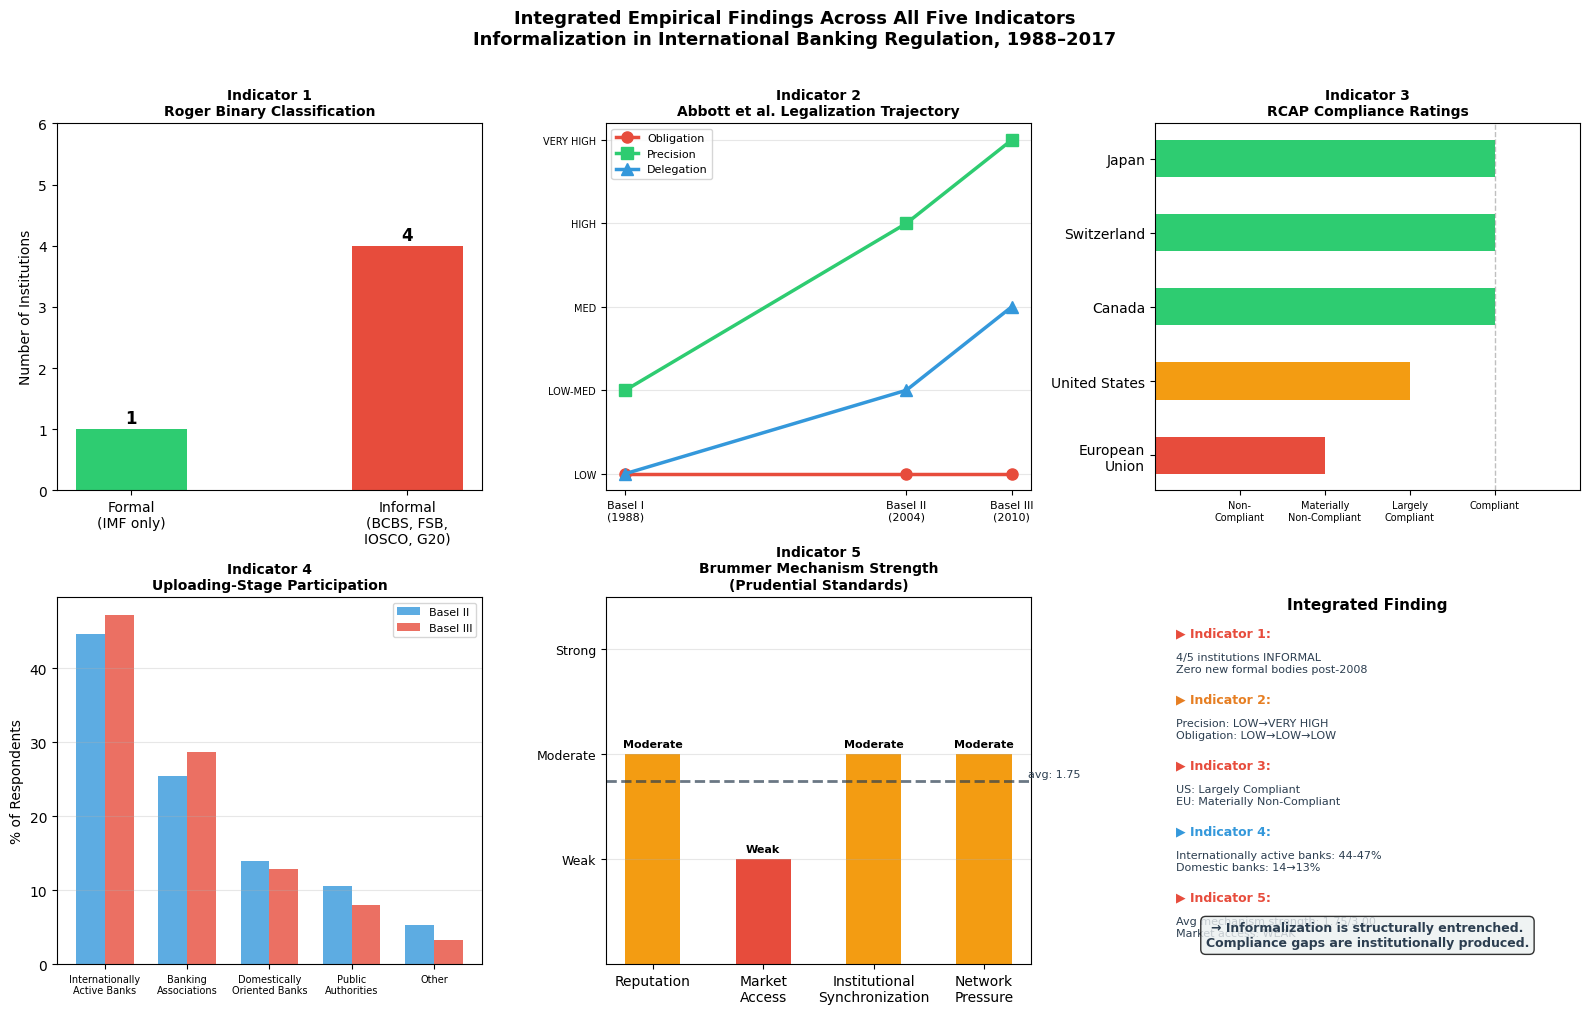

Figure saved to: ../outputs/figures/indicator5_integrated_findings.png


In [5]:
# Integrated findings visualization — summary across all five indicators

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# ── PANEL 1: Indicator 1 — Roger Binary ──
ax1 = axes[0]
formal = 1
informal = 4
ax1.bar(["Formal\n(IMF only)"], [formal], color="#2ecc71", width=0.4)
ax1.bar(["Informal\n(BCBS, FSB,\nIOSCO, G20)"], [informal], color="#e74c3c", width=0.4)
ax1.set_ylim(0, 6)
ax1.set_ylabel("Number of Institutions")
ax1.set_title("Indicator 1\nRoger Binary Classification", 
              fontweight="bold", fontsize=10)
for i, v in enumerate([formal, informal]):
    ax1.text(i, v + 0.1, str(v), ha="center", fontweight="bold", fontsize=12)

# ── PANEL 2: Indicator 2 — Abbott et al. Trajectory ──
ax2 = axes[1]
years = [1988, 2004, 2010]
obligation = [1, 1, 1]
precision = [2, 4, 5]
delegation = [1, 2, 3]
ax2.plot(years, obligation, marker="o", color="#e74c3c", 
         linewidth=2.5, markersize=8, label="Obligation")
ax2.plot(years, precision, marker="s", color="#2ecc71",
         linewidth=2.5, markersize=8, label="Precision")
ax2.plot(years, delegation, marker="^", color="#3498db",
         linewidth=2.5, markersize=8, label="Delegation")
ax2.set_xticks(years)
ax2.set_xticklabels(["Basel I\n(1988)", "Basel II\n(2004)", "Basel III\n(2010)"],
                     fontsize=8)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.set_yticklabels(["LOW", "LOW-MED", "MED", "HIGH", "VERY HIGH"], fontsize=7)
ax2.set_title("Indicator 2\nAbbott et al. Legalization Trajectory",
              fontweight="bold", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# ── PANEL 3: Indicator 3 — RCAP Compliance ──
ax3 = axes[2]
jurisdictions = ["Japan", "Switzerland", "Canada", "United States", "European\nUnion"]
grades = [4, 4, 4, 3, 2]
colors_rcap = ["#2ecc71", "#2ecc71", "#2ecc71", "#f39c12", "#e74c3c"]
bars = ax3.barh(jurisdictions, grades, color=colors_rcap, height=0.5)
ax3.set_xlim(0, 5)
ax3.set_xticks([1, 2, 3, 4])
ax3.set_xticklabels(["Non-\nCompliant", "Materially\nNon-Compliant",
                      "Largely\nCompliant", "Compliant"], fontsize=7)
ax3.set_title("Indicator 3\nRCAP Compliance Ratings",
              fontweight="bold", fontsize=10)
ax3.invert_yaxis()
for jur, grade in zip(["Japan", "Switzerland", "Canada", "United States", "European\nUnion"],
                       ["Led negotiations" if j else "" 
                        for j in [False, False, False, True, True]]):
    pass
ax3.axvline(x=4, color="grey", linewidth=1, linestyle="--", alpha=0.5)

# ── PANEL 4: Indicator 4 — Participation ──
ax4 = axes[3]
categories = ["Internationally\nActive Banks", "Banking\nAssociations",
              "Domestically\nOriented Banks", "Public\nAuthorities", "Other"]
basel2_pct = [44.7, 25.4, 14.0, 10.5, 5.3]
basel3_pct = [47.3, 28.7, 12.8, 8.0, 3.2]
x = np.arange(len(categories))
width = 0.35
ax4.bar(x - width/2, basel2_pct, width, label="Basel II", 
        color="#3498db", alpha=0.8)
ax4.bar(x + width/2, basel3_pct, width, label="Basel III",
        color="#e74c3c", alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(categories, fontsize=7)
ax4.set_ylabel("% of Respondents")
ax4.set_title("Indicator 4\nUploading-Stage Participation",
              fontweight="bold", fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(axis="y", alpha=0.3)

# ── PANEL 5: Indicator 5 — Mechanism Strength ──
ax5 = axes[4]
mechanisms = ["Reputation", "Market\nAccess", "Institutional\nSynchronization",
              "Network\nPressure"]
strengths = [2, 1, 2, 2]
mech_colors = ["#f39c12", "#e74c3c", "#f39c12", "#f39c12"]
bars5 = ax5.bar(mechanisms, strengths, color=mech_colors, width=0.5)
ax5.set_ylim(0, 3.5)
ax5.set_yticks([1, 2, 3])
ax5.set_yticklabels(["Weak", "Moderate", "Strong"], fontsize=9)
ax5.set_title("Indicator 5\nBrummer Mechanism Strength\n(Prudential Standards)",
              fontweight="bold", fontsize=10)
ax5.axhline(y=1.75, color="#2c3e50", linewidth=2, 
            linestyle="--", alpha=0.7)
ax5.text(3.4, 1.78, "avg: 1.75", fontsize=8, color="#2c3e50")
ax5.grid(axis="y", alpha=0.3)
for bar, val in zip(bars5, strengths):
    label = {1: "Weak", 2: "Moderate", 3: "Strong"}[val]
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             label, ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── PANEL 6: Integrated Finding ──
ax6 = axes[5]
ax6.axis("off")
findings = [
    ("Indicator 1", "4/5 institutions INFORMAL\nZero new formal bodies post-2008", "#e74c3c"),
    ("Indicator 2", "Precision: LOW→VERY HIGH\nObligation: LOW→LOW→LOW", "#e67e22"),
    ("Indicator 3", "US: Largely Compliant\nEU: Materially Non-Compliant", "#e74c3c"),
    ("Indicator 4", "Internationally active banks: 44-47%\nDomestic banks: 14→13%", "#3498db"),
    ("Indicator 5", "Avg mechanism strength: 1.75/3.00\nMarket access: WEAK", "#e74c3c"),
]

y_pos = 0.92
ax6.text(0.5, 1.0, "Integrated Finding", ha="center", va="top",
         fontsize=11, fontweight="bold", transform=ax6.transAxes)

for indicator, finding, color in findings:
    ax6.text(0.05, y_pos, f"▶ {indicator}:", ha="left", va="top",
             fontsize=9, fontweight="bold", color=color,
             transform=ax6.transAxes)
    ax6.text(0.05, y_pos - 0.07, finding, ha="left", va="top",
             fontsize=8, color="#2c3e50",
             transform=ax6.transAxes)
    y_pos -= 0.18

ax6.text(0.5, 0.04,
         "→ Informalization is structurally entrenched.\n"
         "Compliance gaps are institutionally produced.",
         ha="center", va="bottom", fontsize=9,
         fontweight="bold", color="#2c3e50",
         transform=ax6.transAxes,
         bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="#ecf0f1", alpha=0.8))

fig.suptitle(
    "Integrated Empirical Findings Across All Five Indicators\n"
    "Informalization in International Banking Regulation, 1988–2017",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/indicator5_integrated_findings.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Figure saved to: ../outputs/figures/indicator5_integrated_findings.png")

In [6]:
# Save all datasets to outputs
df_mechanisms.to_csv("../outputs/indicator5_brummer_mechanisms.csv", index=False)
matrix_df.to_csv("../outputs/indicator5_mechanism_matrix.csv", index=False)

print("Datasets saved:")
print("  ✓ ../outputs/indicator5_brummer_mechanisms.csv")
print("  ✓ ../outputs/indicator5_mechanism_matrix.csv")
print(f"\nMechanisms coded: {len(df_mechanisms)}")
print(f"Matrix entries: {len(matrix_df)}")
print(f"\nFigures saved:")
print("  ✓ ../outputs/figures/indicator5_mechanism_heatmap.png")
print("  ✓ ../outputs/figures/indicator5_integrated_findings.png")

Datasets saved:
  ✓ ../outputs/indicator5_brummer_mechanisms.csv
  ✓ ../outputs/indicator5_mechanism_matrix.csv

Mechanisms coded: 4
Matrix entries: 20

Figures saved:
  ✓ ../outputs/figures/indicator5_mechanism_heatmap.png
  ✓ ../outputs/figures/indicator5_integrated_findings.png
